### PHIST host benchmarking

In [1]:
### Load packages
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
plt.rcParams.update({'font.size': 14})

In [2]:
### Download mOTUs-DB isolates (no already in HRGM2 or HROM)
# !wget https://zenodo.org/records/13325008/files/Supplementary_Table_1.tsv.gz?download=1 -O Supplementary_Table_1.tsv.gz
# !wget https://zenodo.org/records/13325008/files/Supplementary_Table_3.tsv.gz?download=1 -O Supplementary_Table_3.tsv.gz
# !wget https://zenodo.org/records/13325008/files/Supplementary_Table_4.tsv.gz?download=1 -O Supplementary_Table_4.tsv.gz
# downloaded mOTUs-DB metadata by clicking "Export Metadata > All" all here: https://motus-db.org/genome-cols

### Benchmark using UHGV

In [3]:
### Load PHIST hits as LazyFrame (streaming) — ~66M rows, do not collect eagerly

from pathlib import Path

PHIST_TSV = '../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_phist.tsv.gz'
PHIST_SLIM_PARQUET = Path('uhvdb_phist_slim.parquet')

# Cache a slim columnar copy once so threshold sweeps don't re-decompress the 767MB gz
if not PHIST_SLIM_PARQUET.exists():
    (
        pl.scan_csv(
            PHIST_TSV,
            separator='\t',
            schema_overrides={'Containment': pl.Float32},
        )
        .select(['uhvdb_id', 'Containment', 'taxonomy'])
        .rename({'uhvdb_id': 'Target id'})
        .sink_parquet(PHIST_SLIM_PARQUET)
    )
    print(f'Wrote slim cache: {PHIST_SLIM_PARQUET.resolve()}')

phist_hits = pl.scan_parquet(PHIST_SLIM_PARQUET)

phist_stats = (
    phist_hits
    .select([
        pl.len().alias('n_hits'),
        pl.col('Target id').n_unique().alias('n_viruses'),
        pl.col('Containment').min().alias('cmin'),
        pl.col('Containment').max().alias('cmax'),
    ])
    .collect(engine='streaming')
)
print(f'PHIST hits: {phist_stats["n_hits"][0]:,}')
print(f'Unique viruses: {phist_stats["n_viruses"][0]:,}')
print(
    f'Containment range: '
    f'{phist_stats["cmin"][0]:.3f} - {phist_stats["cmax"][0]:.3f}'
)


def consensus_at_threshold(lf, threshold, min_agreement=0.7):
    """Native Polars consensus (no map_elements) for one containment cutoff."""
    base = (
        lf
        .filter(pl.col('Containment') >= threshold)
        .filter(pl.col('taxonomy').is_not_null() & (pl.col('taxonomy').str.strip_chars() != ''))
        .with_columns([
            pl.col('taxonomy').str.extract(r'(?:^|;)\s*(s__[^;]+)', 1).str.strip_chars().alias('s_token'),
            pl.col('taxonomy').str.extract(r'(?:^|;)\s*(g__[^;]+)', 1).str.strip_chars().alias('g_token'),
            pl.col('taxonomy').str.extract(r'(?:^|;)\s*(f__[^;]+)', 1).str.strip_chars().alias('f_token'),
        ])
    )
    totals = base.group_by('Target id').agg(pl.len().alias('total_connections'))

    parts = []
    for rank, col in [('species', 's_token'), ('genus', 'g_token'), ('family', 'f_token')]:
        top = (
            base
            .filter(pl.col(col).is_not_null() & (pl.col(col) != ''))
            .group_by(['Target id', col])
            .agg(pl.len().alias('n'))
            .group_by('Target id')
            .agg([
                pl.col(col).sort_by('n', descending=True).first().alias('consensus_taxonomy'),
                pl.col('n').sort_by('n', descending=True).first().alias('top_count'),
            ])
            .join(totals, on='Target id', how='inner')
            .with_columns((pl.col('top_count') / pl.col('total_connections')).alias('agreement'))
            .filter(pl.col('agreement') >= min_agreement)
            .select([
                'Target id',
                'total_connections',
                pl.lit(rank).alias('rank'),
                'agreement',
                'consensus_taxonomy',
                pl.lit(threshold).alias('containment_threshold'),
            ])
        )
        parts.append(top)
    return pl.concat(parts)


PHIST hits: 66,069,674
Unique viruses: 120,553
Containment range: 0.200 - 1.000


In [4]:
### Consensus host predictions at each containment threshold (streaming collect)
### Collect only the small per-virus summary tables — never the full 66M-row hit table.

THRESHOLDS = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
# Keep all majority calls (min_agreement=0); filter agreement downstream for threshold sweeps
MIN_AGREEMENT_DEFAULT = 0.7

phist_lst = []
for i in THRESHOLDS:
    df_i = consensus_at_threshold(phist_hits, i, min_agreement=0.0).collect(engine='streaming')
    print(f'containment>={i:.2f}: {df_i.height:,} consensus rows')
    phist_lst.append(df_i)

phist_hits_thresholded = pl.concat(phist_lst)
print(f'Total thresholded consensus rows: {phist_hits_thresholded.height:,}')
phist_hits_thresholded.head(3)


containment>=0.20: 361,659 consensus rows
containment>=0.30: 335,112 consensus rows
containment>=0.40: 303,645 consensus rows
containment>=0.50: 269,913 consensus rows
containment>=0.60: 231,729 consensus rows
containment>=0.70: 188,904 consensus rows
containment>=0.80: 146,655 consensus rows
containment>=0.90: 115,647 consensus rows
Total thresholded consensus rows: 1,953,264


Target id,total_connections,rank,agreement,consensus_taxonomy,containment_threshold
str,u32,str,f64,str,f64
"""UHVDB-32768""",1,"""species""",1.0,"""s__CAG-762 sp000432575""",0.2
"""UHVDB-163770""",335,"""species""",0.79403,"""s__Bifidobacterium bifidum""",0.2
"""UHVDB-38911""",40,"""species""",0.65,"""s__Bilophila wadsworthia""",0.2


In [5]:
### load UHGV↔UHVDB ID mapping and join with PHIST host predictions

mapping = (
    pl.scan_csv(
        '../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_mapping.tsv.gz',
        separator='\t',
    )
    .rename({'original_id': 'column_1', 'new_id': 'column_2'})
    .with_columns(pl.col('column_1').str.replace(r'\|provirus.*', ''))
    .collect()
)

uhvdb_host_predictions = (
    phist_hits_thresholded
    .join(mapping, left_on='Target id', right_on='column_2', how='inner')
)

print(uhvdb_host_predictions.shape)
uhvdb_host_predictions.head(2)


(1953264, 7)


Target id,total_connections,rank,agreement,consensus_taxonomy,containment_threshold,column_1
str,u32,str,f64,str,f64,str
"""UHVDB-32768""",1,"""species""",1.0,"""s__CAG-762 sp000432575""",0.2,"""UHGV-0088300"""
"""UHVDB-163770""",335,"""species""",0.79403,"""s__Bifidobacterium bifidum""",0.2,"""UHGV-1958620"""


In [6]:
### analyze UHGV's original phist annotations
hq_votus = (
    pl.read_csv('../figure_s6/votus_metadata_extended.tsv', null_values='NULL', separator='\t', ignore_errors=True, columns=['uhgv_genome', 'checkv_completeness', 'viral_confidence', 'kmers_total_connections', 'kmers_host_agreement', 'kmers_host_lineage_gtdb_r207'])
        .filter(
            (pl.col('checkv_completeness') >= 90) &
            (pl.col('viral_confidence') == 'Confident')
        )
        .with_columns(pl.col('kmers_total_connections').cast(pl.Float64))
        .with_columns(pl.col('kmers_host_agreement').cast(pl.Float64))
        .with_columns([
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';s__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_species'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';g__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_genus'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';f__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_family'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';o__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';o__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_order'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';c__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';c__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_class'),
            pl.when(pl.col('kmers_host_lineage_gtdb_r207').str.contains(';p__')).then(pl.col('kmers_host_lineage_gtdb_r207').str.split(';p__').list[-1].str.split(';').list[0]).otherwise(pl.lit(None)).alias('host_phylum')
        ])
)

# count UHGV PHIST assignments at each rank
print("Total UHGV HQ vOTUs:", hq_votus['uhgv_genome'].n_unique())
print("Number of UHGV HQ vOTUs with predicted hosts from kmer method:", hq_votus.filter(pl.col('kmers_total_connections') > 0)['uhgv_genome'].n_unique())
print("Number with species-level assignments:", hq_votus.filter(pl.col('host_species').is_not_null())['uhgv_genome'].n_unique())
print("Number with genus-level assignments:", hq_votus.filter(pl.col('host_genus').is_not_null())['uhgv_genome'].n_unique())
print("Number with family-level assignments:", hq_votus.filter(pl.col('host_family').is_not_null())['uhgv_genome'].n_unique())
print("Number with order-level assignments:", hq_votus.filter(pl.col('host_order').is_not_null())['uhgv_genome'].n_unique())
print("Number with class-level assignments:", hq_votus.filter(pl.col('host_class').is_not_null())['uhgv_genome'].n_unique())
print("Number with phylum-level assignments:", hq_votus.filter(pl.col('host_phylum').is_not_null())['uhgv_genome'].n_unique())

Total UHGV HQ vOTUs: 57514
Number of UHGV HQ vOTUs with predicted hosts from kmer method: 34222
Number with species-level assignments: 22872
Number with genus-level assignments: 27402
Number with family-level assignments: 30662
Number with order-level assignments: 31344
Number with class-level assignments: 32156
Number with phylum-level assignments: 34222


In [7]:
### Harmonize UHGV GTDB r207 host names to UHVDB GTDB r226
### Build r207→r226 maps by joining shared genomes across GTDB taxonomy releases.

from pathlib import Path

GTDB_TAX_DIR = Path('gtdb_tax')
GTDB_TAX_DIR.mkdir(exist_ok=True)

GTDB_FILES = {
    'r207': [
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release207/207.0/bac120_taxonomy_r207.tsv.gz',
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release207/207.0/ar53_taxonomy_r207.tsv.gz',
    ],
    'r226': [
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release226/226.0/bac120_taxonomy_r226.tsv.gz',
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release226/226.0/ar53_taxonomy_r226.tsv.gz',
    ],
}


def _ensure_gtdb_file(url: str) -> Path:
    dest = GTDB_TAX_DIR / Path(url).name
    if not dest.exists():
        import urllib.request
        print(f'Downloading {dest.name} ...')
        urllib.request.urlretrieve(url, dest)
    return dest


def _load_gtdb_taxonomy(urls):
    frames = []
    for url in urls:
        path = _ensure_gtdb_file(url)
        frames.append(
            pl.read_csv(path, separator='\t', has_header=False, new_columns=['accession', 'lineage'])
        )
    return (
        pl.concat(frames)
        .with_columns(
            pl.col('accession')
            .str.replace(r'^(RS_|GB_)', '')
            .str.replace(r'\.\d+$', '')
            .alias('gid')
        )
    )


def _rank_token(lineage_col: str, rank_prefix: str) -> pl.Expr:
    return (
        pl.when(pl.col(lineage_col).str.contains(f';{rank_prefix}__'))
        .then(
            pl.col(lineage_col)
            .str.split(f';{rank_prefix}__').list.get(-1)
            .str.split(';').list.get(0)
        )
        .otherwise(None)
    )


def build_r207_to_r226_map(rank_prefix: str) -> pl.DataFrame:
    """Majority-vote r207 taxon name → r226 taxon name using shared genome accessions."""
    left = r207_tax.select(['gid', _rank_token('lineage', rank_prefix).alias('r207')])
    right = r226_tax.select(['gid', _rank_token('lineage', rank_prefix).alias('r226')])
    return (
        left.join(right, on='gid', how='inner')
        .filter(pl.col('r207').is_not_null() & pl.col('r226').is_not_null())
        .group_by(['r207', 'r226'])
        .agg(pl.len().alias('n_genomes'))
        .sort(['r207', 'n_genomes'], descending=[False, True])
        .unique(subset=['r207'], keep='first')
        .select(['r207', 'r226', 'n_genomes'])
    )


r207_tax = _load_gtdb_taxonomy(GTDB_FILES['r207'])
r226_tax = _load_gtdb_taxonomy(GTDB_FILES['r226'])

rank_prefix = {'species': 's', 'genus': 'g', 'family': 'f'}
gtdb_maps = {rank: build_r207_to_r226_map(prefix) for rank, prefix in rank_prefix.items()}

for rank, mp in gtdb_maps.items():
    n_changed = mp.filter(pl.col('r207') != pl.col('r226')).height
    print(f'{rank}: {mp.height:,} r207 names mapped; {n_changed:,} renamed in r226')

# Remap UHGV host names into r226 space for fair comparison with UHVDB
hq_votus = hq_votus.with_columns([
    pl.col('host_species')
        .replace_strict(
            dict(zip(gtdb_maps['species']['r207'].to_list(), gtdb_maps['species']['r226'].to_list())),
            default=pl.col('host_species'),
        )
        .alias('host_species_r226'),
    pl.col('host_genus')
        .replace_strict(
            dict(zip(gtdb_maps['genus']['r207'].to_list(), gtdb_maps['genus']['r226'].to_list())),
            default=pl.col('host_genus'),
        )
        .alias('host_genus_r226'),
    pl.col('host_family')
        .replace_strict(
            dict(zip(gtdb_maps['family']['r207'].to_list(), gtdb_maps['family']['r226'].to_list())),
            default=pl.col('host_family'),
        )
        .alias('host_family_r226'),
])

n_species_renamed = hq_votus.filter(
    pl.col('host_species').is_not_null()
    & (pl.col('host_species') != pl.col('host_species_r226'))
).height
print(f'UHGV HQ hosts with remapped species names: {n_species_renamed:,}')

# Shared denominator: HQ genomes present in both UHGV and UHVDB mappings
both_methods = set(
    mapping.join(hq_votus, left_on='column_1', right_on='uhgv_genome', how='inner')['column_1']
)
n_hq_both = len(both_methods)
print(f'Number of HQ vOTUs present in UHGV and UHVDB (denominator): {n_hq_both:,}')


def hosts_match_expr(uhgv_col: str, uhvdb_col: str = 'consensus_taxonomy', rank: str = 'species') -> pl.Expr:
    """Exact match, r226-mapped match, or shared GTDB species placeholder ID (spXXXXXXXXX)."""
    exact = pl.col(uhgv_col) == pl.col(uhvdb_col)
    if rank == 'species':
        uhgv_spid = pl.col(uhgv_col).str.extract(r'sp(\d{9})', 1)
        uhvdb_spid = pl.col(uhvdb_col).str.extract(r'sp(\d{9})', 1)
        spid = uhgv_spid.is_not_null() & (uhgv_spid == uhvdb_spid)
        return exact | spid
    return exact


species: 62,153 r207 names mapped; 8,856 renamed in r226
genus: 16,099 r207 names mapped; 1,194 renamed in r226
family: 3,990 r207 names mapped; 302 renamed in r226
UHGV HQ hosts with remapped species names: 5,276
Number of HQ vOTUs present in UHGV and UHVDB (denominator): 51,406


In [8]:
uhvdb_host_predictions.head(2)

Target id,total_connections,rank,agreement,consensus_taxonomy,containment_threshold,column_1
str,u32,str,f64,str,f64,str
"""UHVDB-32768""",1,"""species""",1.0,"""s__CAG-762 sp000432575""",0.2,"""UHGV-0088300"""
"""UHVDB-163770""",335,"""species""",0.79403,"""s__Bifidobacterium bifidum""",0.2,"""UHGV-1958620"""


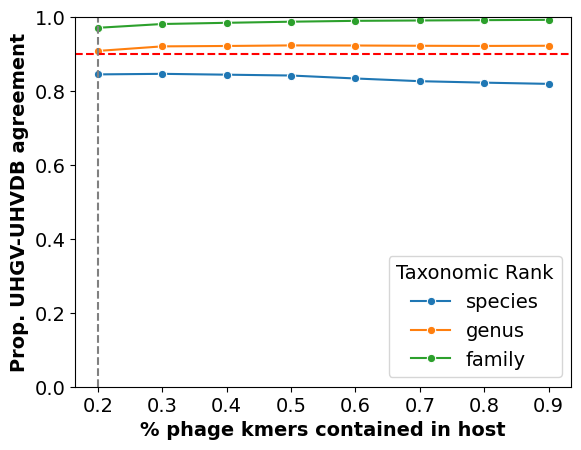

In [9]:
### Compare agreement between original UHGV phist annotations and new annotations
### using varying % kmer containment thresholds
### UHGV hosts are GTDB r226-harmonized (host_*_r226) for fair comparison with UHVDB
recalls = []
precisions = []
f1s = []
num_ks = []
percents = []
props = []
ranks = []

for i in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    for rank in ['species', 'genus', 'family']:#, 'phylum', 'order', 'class', 'phylum']:
        uhgv_col = f'host_{rank}_r226'
        uhvdb_col = f'consensus_{rank}'
        uhgv_phist_annotated = (
            uhvdb_host_predictions
                .filter(pl.col('containment_threshold') == i)
                .filter(pl.col('rank') == rank)
                .filter(pl.col('agreement') >= MIN_AGREEMENT_DEFAULT)
                .with_columns([
                    pl.col('consensus_taxonomy').str.split('__').list[1].alias(uhvdb_col),
                ])
        )

        for num_k in [1]:
            # identify UHVDB agreement with UHGV phist assignments (GTDB-harmonized)
            uhgv_uhvdb_join = (
                hq_votus
                    .filter(pl.col(uhgv_col).is_not_null())
                    .join(uhgv_phist_annotated, left_on='uhgv_genome', right_on='column_1', how='left')
                    .sort(pl.col('kmers_total_connections'))
            )

            matched = hosts_match_expr(uhgv_col, uhvdb_col, rank=rank)
            tp = uhgv_uhvdb_join.filter(matched).height
            fp = uhgv_uhvdb_join.filter((~matched) & pl.col(uhvdb_col).is_not_null()).height
            fn = uhgv_uhvdb_join.filter(pl.col(uhvdb_col).is_null()).height

            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            recalls.append(recall)
            precisions.append(precision)
            f1s.append(f1)
            num_ks.append(num_k)
            percents.append(i)
            props.append(
                uhgv_phist_annotated
                .filter(pl.col('column_1').is_in(both_methods))
                .select('column_1')
                .n_unique()
                / n_hq_both
            )
            ranks.append(rank)

### plot UHGV original vs new phist agreement (% kmer cutoffs)
precision_df = pl.DataFrame({
    'rank': ranks,
    'num_kmers': num_ks,
    'percents': percents,
    'recall': recalls,
    'precision': precisions,
    'f1_score': f1s,
    'proportion_assigned': props
})

# plot results as a seaborn lineplot
sns.lineplot(data=precision_df, x='percents', y='precision', hue='rank', marker='o')
plt.xlabel('% phage kmers contained in host', fontdict={'fontweight': 'bold'})
plt.ylabel('Prop. UHGV-UHVDB agreement', fontdict={'fontweight': 'bold'})
plt.legend(title='Taxonomic Rank')
# horizontal line at y=0.9
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=0.2, color='grey', linestyle='--')
plt.ylim(0,1)
plt.show()

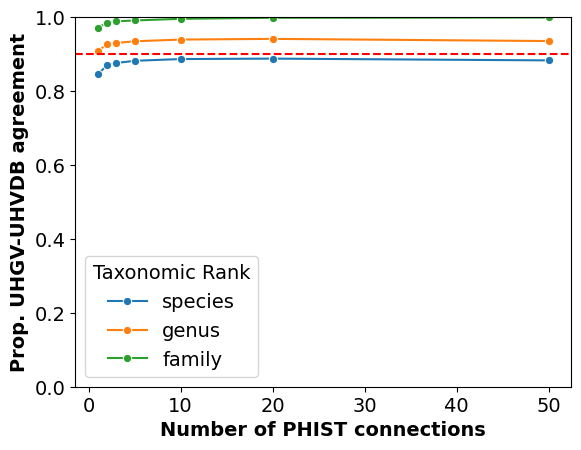

In [10]:
### Compare agreement between original UHGV phist annotations and new annotations
### using a fixed 20% kmer containment threshold and varying minimum host-genome connections
### UHGV hosts are GTDB r226-harmonized (host_*_r226) for fair comparison with UHVDB
recalls = []
precisions = []
f1s = []
num_ks = []
min_connections = []
props = []
ranks = []

for rank in ['species', 'genus', 'family']:#, 'phylum', 'order', 'class', 'phylum']:
    uhgv_col = f'host_{rank}_r226'
    uhvdb_col = f'consensus_{rank}'
    uhgv_phist_annotated = (
        uhvdb_host_predictions
            .filter(pl.col('containment_threshold') == 0.2)
            .filter(pl.col('rank') == rank)
            .filter(pl.col('agreement') >= MIN_AGREEMENT_DEFAULT)
            .with_columns([
                pl.col('consensus_taxonomy').str.split('__').list[1].alias(uhvdb_col),
            ])
    )

    for min_conn in [1, 2, 3, 5, 10, 20, 50]:
        # identify UHVDB agreement with UHGV phist assignments (GTDB-harmonized)
        uhgv_uhvdb_join = (
            hq_votus
                .filter(pl.col(uhgv_col).is_not_null())
                .join(uhgv_phist_annotated, left_on='uhgv_genome', right_on='column_1', how='left')
                .sort(pl.col('kmers_total_connections'))
        )

        matched = hosts_match_expr(uhgv_col, uhvdb_col, rank=rank)
        tp = uhgv_uhvdb_join.filter(matched & (pl.col('total_connections') >= min_conn)).height
        fp = uhgv_uhvdb_join.filter((~matched) & pl.col(uhvdb_col).is_not_null() & (pl.col('total_connections') >= min_conn)).height
        fn = uhgv_uhvdb_join.filter(pl.col(uhvdb_col).is_null() | (pl.col('total_connections') < min_conn)).height

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        recalls.append(recall)
        precisions.append(precision)
        f1s.append(f1)
        num_ks.append(min_conn)
        min_connections.append(min_conn)
        props.append(
            uhgv_phist_annotated
            .filter(pl.col('total_connections') >= min_conn)
            .filter(pl.col('column_1').is_in(both_methods))
            .select('column_1')
            .n_unique()
            / n_hq_both
        )
        ranks.append(rank)

# Backward-compatible alias for downstream cells that still expect `percents`
percents = min_connections

### plot UHGV original vs new phist agreement (minimum host-genome connections at fixed 20% containment)
precision_df = pl.DataFrame({
    'rank': ranks,
    'num_kmers': num_ks,
    'percents': percents,
    'recall': recalls,
    'precision': precisions,
    'f1_score': f1s,
    'proportion_assigned': props
})

# plot results as a seaborn lineplot
sns.lineplot(data=precision_df, x='percents', y='precision', hue='rank', marker='o')
plt.xlabel('Number of PHIST connections', fontdict={'fontweight': 'bold'})
plt.ylabel('Prop. UHGV-UHVDB agreement', fontdict={'fontweight': 'bold'})
plt.legend(title='Taxonomic Rank')
# horizontal line at y=0.9
plt.axhline(y=0.9, color='r', linestyle='--')
plt.ylim(0,1)
plt.show()

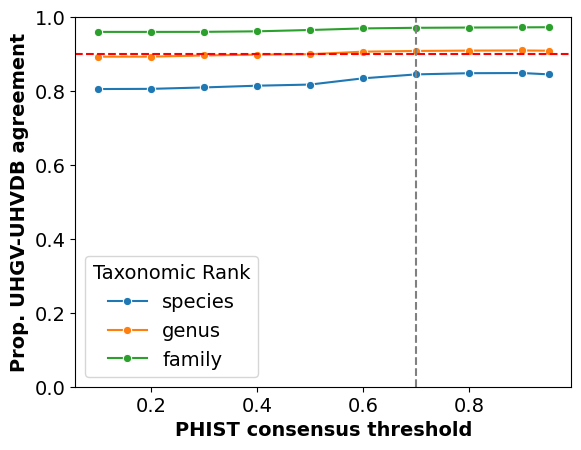

In [11]:
### Agreement vs PHIST consensus threshold (majority-host fraction among hits)
### Fixed at 20% kmer containment and >= 2 connections; UHGV hosts are GTDB r226-harmonized

recalls = []
precisions = []
f1s = []
props = []
ranks = []
agreements = []

AGREEMENT_THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
MIN_CONNECTIONS = 1

for rank in ['species', 'genus', 'family']:
    uhgv_col = f'host_{rank}_r226'
    uhvdb_col = f'consensus_{rank}'
    for agreement in AGREEMENT_THRESHOLDS:
        uhgv_phist_annotated = (
            uhvdb_host_predictions
            .filter(pl.col('containment_threshold') == 0.2)
            .filter(pl.col('rank') == rank)
            .filter(pl.col('agreement') >= agreement)
            .filter(pl.col('total_connections') >= MIN_CONNECTIONS)
            .with_columns([
                pl.col('consensus_taxonomy').str.split('__').list[1].alias(uhvdb_col),
            ])
        )

        uhgv_uhvdb_join = (
            hq_votus
            .filter(pl.col(uhgv_col).is_not_null())
            .join(uhgv_phist_annotated, left_on='uhgv_genome', right_on='column_1', how='left')
        )

        matched = hosts_match_expr(uhgv_col, uhvdb_col, rank=rank)
        tp = uhgv_uhvdb_join.filter(matched).height
        fp = uhgv_uhvdb_join.filter((~matched) & pl.col(uhvdb_col).is_not_null()).height
        fn = uhgv_uhvdb_join.filter(pl.col(uhvdb_col).is_null()).height

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        recalls.append(recall)
        precisions.append(precision)
        f1s.append(f1)
        props.append(
            uhgv_phist_annotated
            .filter(pl.col('column_1').is_in(both_methods))
            .select('column_1')
            .n_unique()
            / n_hq_both
        )
        ranks.append(rank)
        agreements.append(agreement)

agreement_df = pl.DataFrame({
    'rank': ranks,
    'recall': recalls,
    'precision': precisions,
    'f1_score': f1s,
    'proportion_assigned': props,
    'agreement_threshold': agreements,
})

### Plot agreement vs consensus threshold
sns.lineplot(
    data=agreement_df.to_pandas(),
    x='agreement_threshold',
    y='precision',
    hue='rank',
    marker='o',
)
plt.xlabel('PHIST consensus threshold', fontdict={'fontweight': 'bold'})
plt.ylabel('Prop. UHGV-UHVDB agreement', fontdict={'fontweight': 'bold'})
plt.legend(title='Taxonomic Rank')
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axvline(x=0.7, color='grey', linestyle='--')
plt.ylim(0, 1)
plt.show()


In [12]:
### Identify number of HQ vOTUs present in both UHGV and UHVDB (denominator)
# Defined earlier after GTDB harmonization; reprint for notebook readability
print("Number of HQ vOTUs present in UHGV and UHVDB (denominator):", n_hq_both)

Number of HQ vOTUs present in UHGV and UHVDB (denominator): 51406


rank,proportion_annotated,Method,num_annotated,num_total
str,f64,str,i64,i64
"""species""",0.453274,"""UHVDB""",23301,51406
"""species""",0.402716,"""UHGV""",20702,51406
"""genus""",0.554099,"""UHVDB""",28484,51406
"""genus""",0.482512,"""UHGV""",24804,51406
"""family""",0.584348,"""UHVDB""",30039,51406
"""family""",0.537505,"""UHGV""",27631,51406


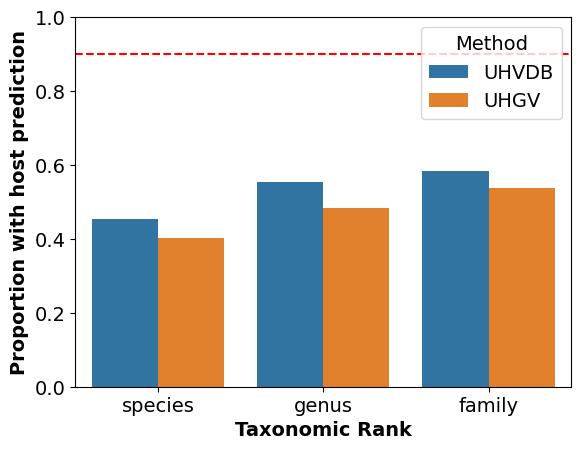

In [13]:
### Proportion annotated at each rank (fixed: >= 2 connections, agreement >= 0.7)
MIN_CONNECTIONS = 1
hq_total = n_hq_both

props = []
methods = []
ranks = []
num_annotated = []
num_total = []

for rank in ['species', 'genus', 'family']:
    # UHVDB PHIST-derived, fixed at 20% containment
    uhvdb_annotated = (
        uhvdb_host_predictions
        .filter(pl.col('containment_threshold') == 0.2)
        .filter(pl.col('rank') == rank)
        .filter(pl.col('agreement') >= MIN_AGREEMENT_DEFAULT)
        .filter(pl.col('total_connections') >= MIN_CONNECTIONS)
        .filter(pl.col('column_1').is_in(both_methods))
        .select('column_1')
        .unique()
        .height
    )
    props.append(uhvdb_annotated / hq_total if hq_total > 0 else 0)
    methods.append('UHVDB')
    ranks.append(rank)
    num_annotated.append(uhvdb_annotated)
    num_total.append(hq_total)

    # Original UHGV annotations
    uhgv_old = (
        hq_votus
        .filter(pl.col('uhgv_genome').is_in(both_methods))
        .filter(pl.col(f'host_{rank}').is_not_null())
        .filter(pl.col('kmers_host_agreement') >= MIN_AGREEMENT_DEFAULT)
        .filter(pl.col('kmers_total_connections') >= MIN_CONNECTIONS)
        .select('uhgv_genome')
        .unique()
        .height
    )
    props.append(uhgv_old / hq_total if hq_total > 0 else 0)
    methods.append('UHGV')
    ranks.append(rank)
    num_annotated.append(uhgv_old)
    num_total.append(hq_total)

annotation_rate_df = pl.DataFrame({
    'rank': ranks,
    'proportion_annotated': props,
    'Method': methods,
    'num_annotated': num_annotated,
    'num_total': num_total,
})
display(annotation_rate_df)

sns.barplot(
    data=annotation_rate_df.to_pandas(),
    x='rank',
    y='proportion_annotated',
    hue='Method',
)
plt.xlabel('Taxonomic Rank', fontdict={'fontweight': 'bold'})
plt.ylabel('Proportion with host prediction', fontdict={'fontweight': 'bold'})
plt.ylim(0, 1)
plt.axhline(y=0.9, color='r', linestyle='--')
plt.legend(title='Method')
plt.show()
